In [1]:
from xara_prism import CantileverColumn, BasicShape, PlotSpan, PlotPoint, check_span
from xara_prism.loading import ShearForce
from xara_prism.solutions.reissner_terminal import ReissnerTerminalCantilever
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#<hide>
import thesis

In [3]:
L = 100.0
A = 1.61538e8
I = 3.5e7
Pmax = 150e3
shape = BasicShape(
    E=1,
    G=1,
    A=A,
    Ay=A,
    Az=A,
    Iy=I,#*100,
    Iz=I,
    J =I
)

column = CantileverColumn(length=L, shape=shape, shear=1, smax=1.0, loads=[
    ShearForce(Pmax, x=L, scale="linear", follower=True)
])


## Solution

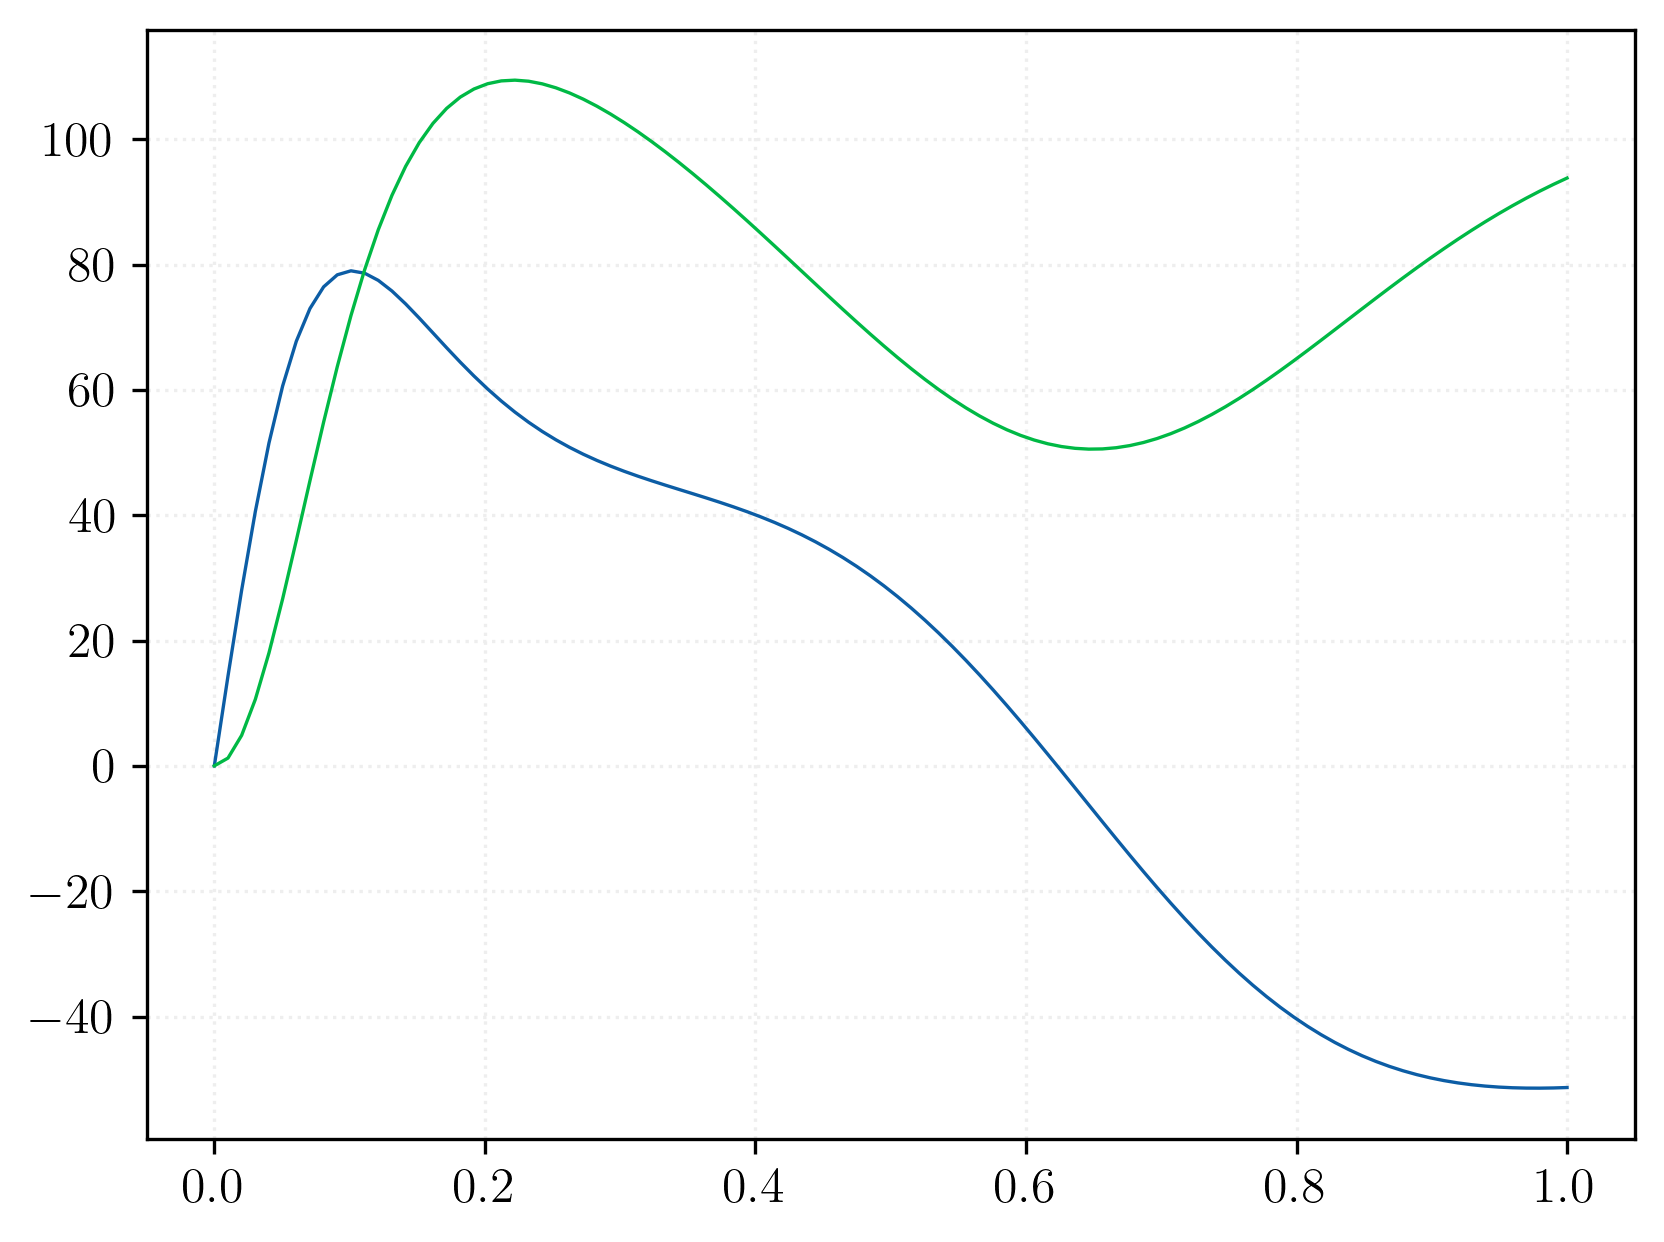

In [4]:
solution = ReissnerTerminalCantilever(column)

time = np.linspace(0, 1.0, 100)

fig, ax = plt.subplots()
ax.plot(time, 
        [solution.u_tran(L, s) for s in time]
)
ax.plot(time, 
        [-solution.u_long(L, s) for s in time]
)

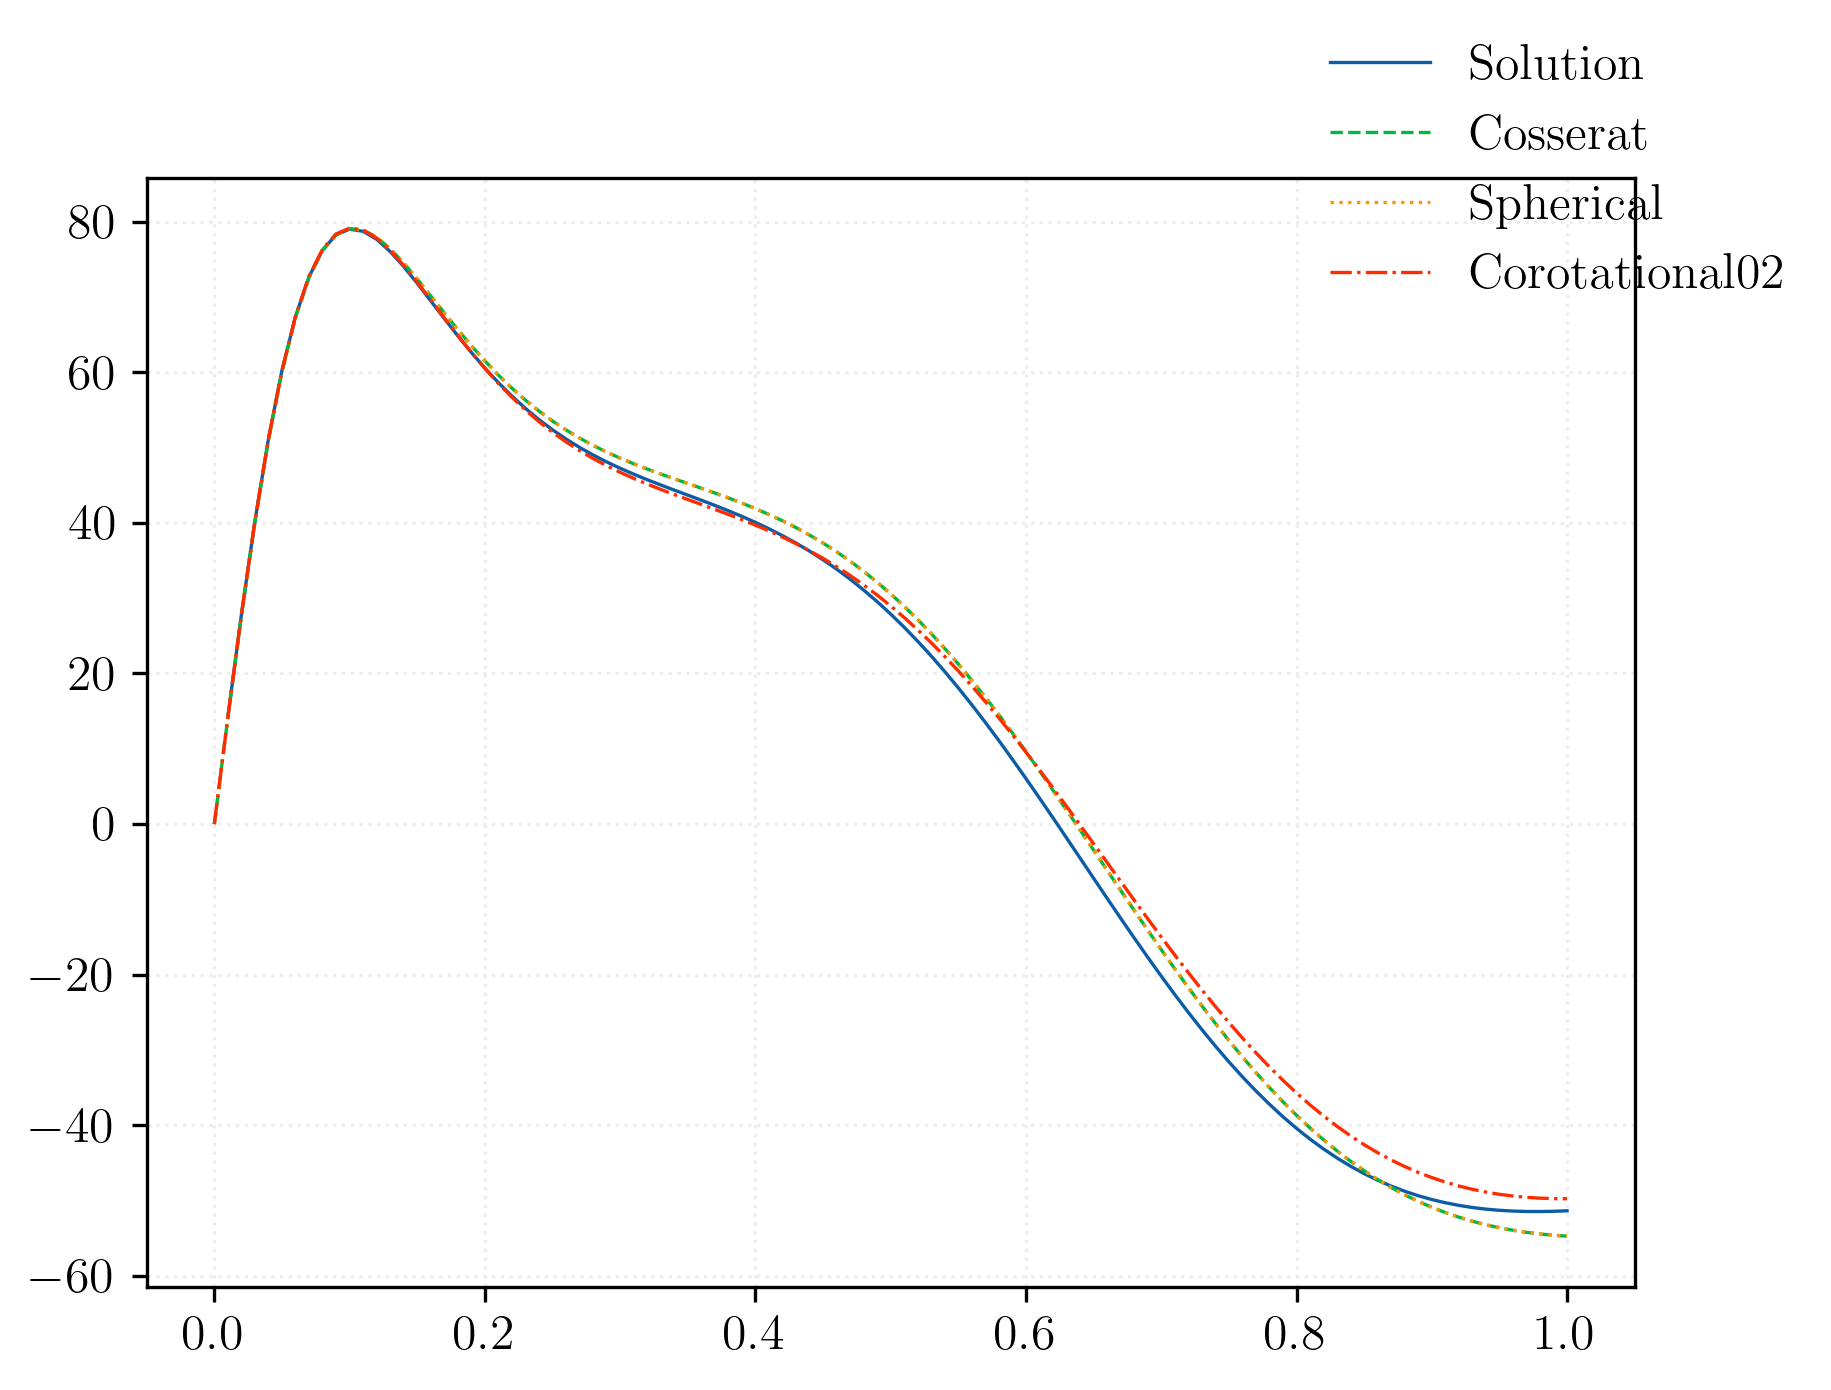

In [5]:
steps = 100
time = np.linspace(1/steps, 1.0, steps)
p = PlotPoint(column, x="time", y="u_tran", loc=L, time=time)
p.add(solution, label="Solution")

p.add(column.analyze(3, "CosseratFrame01", "Identity", ne=10, nen=2, steps=steps, 
                   analysis_options={"test": ("NormDispIncr", 1e-12, 10)}),
                #    marker="x", 
                   ls="--",
                   label="Cosserat"
)


p.add(column.analyze(3, "CosseratFrame01", "Spherical", ne=10, nen=2, steps=steps, 
                   analysis_options={"test": ("NormDispIncr", 1e-10, 15)}),
                #    marker="x", 
                   ls=":",
                   label="Spherical"
)

# # TODO(ShearFrame)
# p.add(span.analyze(3, "ShearFrame", "Corotational02", ne=10, nen=2, steps=steps, 
#                    analysis_options={"test": ("NormDispIncr", 1e-10, 150)}),
#                 #    marker=".", 
#                    ls="-.",
#                    label="Shear"
# )

p.add(column.analyze(3, "ForceFrame", "Corotational02", ne=10, nen=2, steps=steps, 
                   analysis_options={"test": ("NormDispIncr", 1e-12, 10)}),
                #    marker=".", 
                   ls="-.",
                   label="Corotational02"
)
p.ax.figure.legend()

In [6]:
Cases = [
    {"element": "ExactFrame", "transform": "Linear"},
    {"element": "CosseratFrame01", "transform": "Spherical"},
    {"element": "ForceFrame", "transform": "Corotational02"}
]
analysis_options = {"test": ("NormDispIncr", 1e-10, 15)}
loading_options = {"point_basis": "director"}

for case in Cases:
    check_span(
        column.analyze(3, **case, ne=10, nen=2, steps=steps, 
                    analysis_options=analysis_options),
        solution,
        time=[1/steps, 1.0],
        space=[column.length]
    )

AnalysisOutput(ExactFrame/Linear, ne=10, nen=2) ReissnerTerminalCantilever(shear=1)
  time      x │ u_long_out   u_long_sol         diff │ u_tran_out   u_tran_sol         diff
──────      ─ │ ──────────   ──────────   ───────────┼ ──────────   ──────────   ──────────
 0.010    100 │    -1.2090      -1.2167   -6.309e-03 │    14.1486      14.1841   -2.506e-03 │       5
 1.000    100 │   -89.1353     -93.7931   -4.966e-02 │   -54.6984     -51.3305    6.561e-02 │       6

AnalysisOutput(CosseratFrame01/Spherical, ne=10, nen=2) ReissnerTerminalCantilever(shear=1)
  time      x │ u_long_out   u_long_sol         diff │ u_tran_out   u_tran_sol         diff
──────      ─ │ ──────────   ──────────   ───────────┼ ──────────   ──────────   ──────────
 0.010    100 │    -1.2090      -1.2167   -6.309e-03 │    14.1486      14.1841   -2.506e-03 │       5
 1.000    100 │   -89.1353     -93.7931   -4.966e-02 │   -54.6984     -51.3305    6.561e-02 │       6

AnalysisOutput(ForceFrame/Corotational02, ne=1